Verbeek Case Ch 7

In [16]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#statsmodels
import statsmodels.api as sm

#Scikit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split, cross_val_predict

#torch
import torch
import torch.nn as nn
import torch.utils.data as Data
from torch.autograd import Variable

#captum
from captum.attr import IntegratedGradients
from captum.attr import LayerConductance
from captum.attr import NeuronConductance

def func_turn_df_into_t_float(df_arg):
    t_ret = torch.from_numpy(np.array(df_arg))
    t_ret = t_ret.to(torch.float)
    return t_ret

def func_turn_df_into_t_long(df_arg):
    t_ret = torch.from_numpy(np.array(df_arg))
    t_ret = t_ret.to(torch.long)
    return t_ret



In [17]:
print(torch.__version__)

cuda = True
if not torch.cuda.is_available():
    cuda = False
device = torch.device("cuda" if cuda else "cpu")

1.12.1


In [18]:
mySEED = 2023
myRANDOM_STATE = mySEED # for split train/eval

seed=2023
#helper fct
def set_seed_everywhere(seed, cuda):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed_all(seed)    
        
set_seed_everywhere(mySEED,cuda)

myTEST_PERCENTAGE = 0.1

targetDirectory = "C:\\CASES\\PYTPRA"
os.chdir(targetDirectory)#hier sucht Python nach csv Datei


In [19]:
data = pd.read_csv('CaseRating.csv', delimiter=';', decimal = ',') # STROKE
# Überprüfen auf redundante und/oder NaN Daten
if data.duplicated().sum() > 0:
    data = data.drop_duplicates()
    print('Redundante Daten wurden entfernt.')
    print('--------------------------')

if data.isna().any().sum() > 0:
    data = data.dropna()
    print('NaN-Daten wurden entfernt.')
    print('--------------------------')
print(data.shape)
print(data.head())
print(data.describe())
print("Working directory in use: ", os. getcwd())

(921, 8)
    BOOKLEV      EBIT  INVGRADE   LOGSALES   MARKLEV  RATING      RETA  \
0  0.256678  0.057610         0   6.316473  0.212763       2 -0.107975   
1  0.498220  0.003255         0   9.938469  0.783435       2 -0.106866   
2  0.227633  0.166818         1  10.011795  0.098529       6  0.382622   
3  0.467678 -0.029463         0   8.430120  0.644844       2 -0.143088   
4  0.000000  0.034412         0   7.291656  0.000000       3  0.285224   

        WKA  
0  0.229022  
1 -0.073097  
2  0.136251  
3  0.031825  
4  0.650847  
          BOOKLEV        EBIT    INVGRADE    LOGSALES     MARKLEV      RATING  \
count  921.000000  921.000000  921.000000  921.000000  921.000000  921.000000   
mean     0.293187    0.093892    0.472313    7.995754    0.254729    3.499457   
std      0.173534    0.084364    0.499504    1.497413    0.187970    1.134561   
min      0.000000   -0.384169    0.000000    1.100278    0.000000    1.000000   
25%      0.169804    0.051201    0.000000    6.970391    

In [20]:
X = data[['BOOKLEV', 'EBIT', 'LOGSALES', 'RETA', 'WKA']]
y = data['INVGRADE']


# Datensatz in Trainings- und Testdaten aufteilen

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=myTEST_PERCENTAGE, random_state=myRANDOM_STATE)

x_temp = sm.add_constant(X_train)
log_reg = sm.Logit(y_train, x_temp).fit()
print(log_reg.summary())
print(np.exp(1.0778))

Optimization terminated successfully.
         Current function value: 0.376108
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               INVGRADE   No. Observations:                  828
Model:                          Logit   Df Residuals:                      822
Method:                           MLE   Df Model:                            5
Date:                Thu, 13 Feb 2025   Pseudo R-squ.:                  0.4566
Time:                        14:34:05   Log-Likelihood:                -311.42
converged:                       True   LL-Null:                       -573.05
Covariance Type:            nonrobust   LLR p-value:                7.558e-111
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.2236      0.915     -8.990      0.000     -10.016      -6.431
BOOKLEV       -4.1983      0.

In [21]:
# Standardisierung
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
#prep torch data
t_X_train = func_turn_df_into_t_float(X_train_scaled)
t_X_valid = func_turn_df_into_t_float(X_test_scaled)

t_y_train = func_turn_df_into_t_long(y_train)
t_y_valid = func_turn_df_into_t_long(y_test)

In [23]:
myHIDDENone = 4 #we have 5 dim input + 1 out = 6, two thirds = 4
myMAX_EPOCHS = 50 #2000 too much
myLEARNING_RATE = 0.1
myBATCH_SIZE = 32 #32 is min

In [24]:
#PyTorch MLP

torch_dataset = Data.TensorDataset(t_X_train, t_y_train)
train_loader = Data.DataLoader(
    dataset=torch_dataset, 
    batch_size=myBATCH_SIZE, 
    shuffle=True, num_workers=0,)#only one subprocess needed

model_pt = nn.Sequential(nn.Linear(5, myHIDDENone),
                      nn.Sigmoid(),
                      nn.Linear(myHIDDENone, 2), nn.Softmax(dim=1))

In [25]:
loss_fn = nn.CrossEntropyLoss() #watch this!
optimizer =  torch.optim.Adam(model_pt.parameters(), lr=myLEARNING_RATE)
#torch.optim.SGD(model_pt.parameters(), lr=0.5) is worse
losses_train = []
losses_val = []

def generic_training_loop_extended(n_epochs, optimizer, model, loss_fn, train_t_u, val_t_u,train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        loss_train_avg = []
        for step, (batch_x, batch_y) in enumerate(train_loader): 
            b_x = Variable(batch_x)
            b_y = Variable(batch_y)
            train_t_p = model(b_x) #all details are in model
            train_loss = loss_fn(train_t_p, b_y) #and the loss function
            loss_train_avg.append(train_loss.item()) 
            optimizer.zero_grad()
            train_loss.backward() 
            optimizer.step()
        with torch.no_grad(): 
            val_t_p = model(val_t_u)
            val_loss = loss_fn(val_t_p, val_t_c)
            losses_val.append(val_loss.item()) 
            assert val_loss.requires_grad == False 
        losses_train.append(train_loss.item()) 
        if epoch <= 100 or epoch % 50 == 0:
            print("Epoch", {epoch}, f"Avg. training loss over all batches: {np.average(loss_train_avg[0:step]):.4f}", 
                  f"Validation loss:  {val_loss.item():.4f}",
                  "\n \tLast batch out of", {step}, f"has training loss: {train_loss.item():.4f}")    
    
    return 

generic_training_loop_extended(n_epochs = myMAX_EPOCHS, optimizer = optimizer, model = model_pt,
                      loss_fn = loss_fn , train_t_u = t_X_train, val_t_u = t_X_valid, 
                      train_t_c = t_y_train, val_t_c = t_y_valid)

Epoch {1} Avg. training loss over all batches: 0.5473 Validation loss:  0.4629 
 	Last batch out of {25} has training loss: 0.4869
Epoch {2} Avg. training loss over all batches: 0.4975 Validation loss:  0.4510 
 	Last batch out of {25} has training loss: 0.5495
Epoch {3} Avg. training loss over all batches: 0.4866 Validation loss:  0.4509 
 	Last batch out of {25} has training loss: 0.4962
Epoch {4} Avg. training loss over all batches: 0.4814 Validation loss:  0.4361 
 	Last batch out of {25} has training loss: 0.5035
Epoch {5} Avg. training loss over all batches: 0.4824 Validation loss:  0.4388 
 	Last batch out of {25} has training loss: 0.4788
Epoch {6} Avg. training loss over all batches: 0.4798 Validation loss:  0.4385 
 	Last batch out of {25} has training loss: 0.5070
Epoch {7} Avg. training loss over all batches: 0.4777 Validation loss:  0.4332 
 	Last batch out of {25} has training loss: 0.5519
Epoch {8} Avg. training loss over all batches: 0.4802 Validation loss:  0.4347 
 	L

In [26]:
#inspect model
ig = IntegratedGradients(model_pt)#Specifically, integrated gradients
#are defined as the path intergral of the gradients along the straightline path
#see https://arxiv.org/pdf/1703.01365.pdf
ig_input_tensor = t_X_train
ig_input_tensor.requires_grad_()
attr, delta = ig.attribute(ig_input_tensor,target=0, return_convergence_delta=True)
#target class No 0 because we only have one output dimension
attr = attr.detach().numpy()
np.round(attr,2)
importances = np.mean(attr, axis=0)
feature_names = list(X_train.columns)
for i in range(len(feature_names)):
        print(feature_names[i], ": ", '%.3f'%(importances[i]))

BOOKLEV :  0.018
EBIT :  0.116
LOGSALES :  0.107
RETA :  -0.015
WKA :  0.038


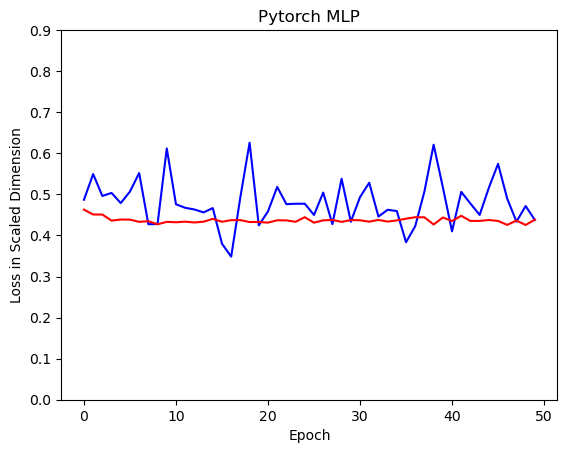

In [27]:
t_ctr = torch.arange(0, myMAX_EPOCHS, step = 1)
#t_ctr = t_ctr.clone().detach().unsqueeze(1)
plt.plot(t_ctr, losses_train, 'b') # plotting separately 
plt.plot(t_ctr, losses_val, 'r') 
plt.ylabel('Loss in Scaled Dimension')
plt.xlabel('Epoch')
plt.title('Pytorch MLP')
plt.ylim(top = 0.9)
plt.ylim(bottom = 0)
plt.show()

In [28]:
#forecast Logit
x_temp = sm.add_constant(X_train)
yhat_train = log_reg.predict(x_temp)
prediction_train = list(map(round, yhat_train))
x_temp = sm.add_constant(X_test)
yhat_test = log_reg.predict(x_temp)
prediction_test = list(map(round, yhat_test))

In [29]:
#forecasts MLP
out_probs_val = model_pt(t_X_valid).detach().numpy()
print(out_probs_val)
out_classes_val = np.argmax(out_probs_val, axis=1)
print(out_classes_val)

out_probs_train = model_pt(t_X_train).detach().numpy()
out_classes_train = np.argmax(out_probs_train, axis=1)

[[4.36847295e-05 9.99956369e-01]
 [8.43875110e-01 1.56124949e-01]
 [8.73099118e-02 9.12690103e-01]
 [1.00000000e+00 1.32334421e-09]
 [9.97419000e-01 2.58105644e-03]
 [1.00000000e+00 1.33882083e-09]
 [5.06819670e-05 9.99949336e-01]
 [7.95832966e-06 9.99992013e-01]
 [9.74792420e-06 9.99990225e-01]
 [9.87504423e-01 1.24955941e-02]
 [8.00283851e-06 9.99992013e-01]
 [8.47519338e-01 1.52480692e-01]
 [9.99998689e-01 1.25523047e-06]
 [8.05408345e-04 9.99194562e-01]
 [7.28792623e-02 9.27120745e-01]
 [1.83463580e-05 9.99981642e-01]
 [9.71636832e-01 2.83632353e-02]
 [8.15324165e-06 9.99991894e-01]
 [8.15170279e-06 9.99991894e-01]
 [9.63884395e-06 9.99990344e-01]
 [9.99999642e-01 3.85522355e-07]
 [7.95787400e-06 9.99992013e-01]
 [9.84696269e-01 1.53037095e-02]
 [9.93992269e-01 6.00771746e-03]
 [9.99999166e-01 8.30730642e-07]
 [9.99834776e-01 1.65184159e-04]
 [9.99321938e-01 6.78130076e-04]
 [1.66554775e-04 9.99833465e-01]
 [6.09153125e-04 9.99390841e-01]
 [8.06623484e-06 9.99991894e-01]
 [1.000000

In [30]:
print("\nCOMPARISON ON TEST SET=================")
print('Number of exercises in test data', sum(y_test))
print('As percentage %.3f ' %  (sum(y_test)/len(y_test)))
print('Benchmark Accuracy on train data %.3f '%  (1-sum(y_train)/len(y_train)))
print('Benchmark Accuracy on test data %.3f \n' %  (1-sum(y_test)/len(y_test)))

print('Accuracy  Logit on train data: %.3f ' % accuracy_score(y_train, prediction_train))
print('Confusion Matrix Logit on train data: \n', confusion_matrix(y_train, prediction_train))
print('Accuracy  Logit on test data: %.3f ' % accuracy_score(y_test, prediction_test))
#print('Precision Logit on test data: %.3f ' %  precision_score(y_test, prediction))
print('Confusion Matrix Logit on test data: \n', confusion_matrix(y_test, prediction_test))

#The precision is the ratio tp / (tp + fp) where tp is the number of true positives 
#and fp the number of false positives. The precision is intuitively 
#the ability of the classifier not to label as positive a sample that is negative.
#the best value is 1 and the worst value is 0.
#print('Benchmark Accuracy on test data %.3f \n' %  (1-sum(y_test)/len(y_test)))
print('Accuracy  MLP on train data: %.3f ' % (sum(out_classes_train == y_train) / len(y_train)))
print('Confusion Matrix MLP on train data:\n', confusion_matrix(y_train, out_classes_train))
print('Accuracy  MLP on test data: %.3f ' % (sum(out_classes_val == y_test) / len(y_test)))
print('Confusion Matrix MLP on test data:\n', confusion_matrix(y_test, out_classes_val))
print("\nXXX DONE XXX")


COMPARISON ON TEST SET=================
Number of exercises in test data 40
As percentage 0.430 
Benchmark Accuracy on train data 0.523 
Benchmark Accuracy on test data 0.570 

Accuracy  Logit on train data: 0.827 
Confusion Matrix Logit on train data: 
 [[364  69]
 [ 74 321]]
Accuracy  Logit on test data: 0.860 
Confusion Matrix Logit on test data: 
 [[43 10]
 [ 3 37]]
Accuracy  MLP on train data: 0.864 
Confusion Matrix MLP on train data:
 [[378  55]
 [ 58 337]]
Accuracy  MLP on test data: 0.871 
Confusion Matrix MLP on test data:
 [[45  8]
 [ 4 36]]

XXX DONE XXX
